# Coronagraphs & Multi-Plane Optical Systems

This tutorial is designed to be an exploration of how we can construct more complex optical systems with multiple planes, such as a coronograph. We will also use this as a way to explore how to create custom and parametric layers. It highlights dLux's focus on flexibility and composability, designed to be a optical modelling _framework_, rather than a another optical modelling package. We will also see two different ways of constructing a coronagraphs, one using internal FFT's and one using the algorithm from Soummer et al. 2007 to model complex high-res focal plane masks without needing to propagate very large wavefronts.

This tutorial will be broken up into these sections:

1. Building a Multi-Plane Optical System
2. Building the Focal Plane Mask and Lyot Stop
3. Coronagraph Optimisation
4. A Soummer MFT-style Coronagraph

In [1]:
## COLLAPSE: Imports
# Basic imports
import jax.numpy as np
import jax.random as jr
from jax import vmap

# # Optimisation imports
import equinox as eqx
import zodiax as zdx
import optax

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 90

# Nan friendly colormapping
inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

---

## Building the Multi-Plane Optical System

We will follow our previous tutorials and construct a Euclid-like telescope, but this time we will see what it would look like if we had a basic coronagraph in the system. We start here by making the aperture and aberrations of the system as in previous tutorials.

In [2]:
# Define our wavefront properties
wf_npix = 256  # Number of pixels in the wavefront
diameter = 1.0  # Diameter of the wavefront, meters

# Define our detector properties
psf_npix = 64  # Number of pixels in the PSF
psf_pixel_scale = 50e-3  # 50 mili-arcseconds

# Generate a euclid-like aperture and Zernike
m2_diam = 0.2 # Secondary diameter
spider_width = 0.05 # Spider width
aper, basis = dlu.euclid_like(
    npixels=wf_npix,
    diameter=diameter,
    secondary_diameter=m2_diam,
    spider_width=spider_width,
    zernike_nolls=np.arange(4, 22),
)

# Normalise the basis to nm and generate some random coefficients
basis *= 1e-9
coeffs = 5 * jr.normal(jr.key(0), basis.shape[0])

# Define the optical layers
layers = [
    ("aperture", dl.TransmissiveLayer(aper, normalise=True)),
    ("aberrations", dl.BasisLayer(basis, coeffs)),
    ("to_focal", dl.FFT(pad=4)),
    ("from_focal", dl.FFT(crop=4)),
]

# Construct the optics object
optics = dl.AngularOpticalSystem(
    wf_npixels=wf_npix,
    diameter=diameter,
    layers=layers,
    psf_npixels=psf_npix,
    psf_pixel_scale=psf_pixel_scale,
)

# Examine the optics object
print(optics)

AngularOpticalSystem(
  wf_npixels=256,
  diameter=1.0,
  layers={
    'aperture': TransmissiveLayer(transmission=f32[256,256], normalise=True),
    'aberrations':
    BasisLayer(basis=f32[18,256,256], coefficients=f32[18], as_phase=False),
    'to_focal': FFT(focal_length=None, pad=4, crop=1),
    'from_focal': FFT(focal_length=None, pad=1, crop=4)
  },
  psf_npixels=64,
  oversample=1,
  psf_pixel_scale=0.05
)


Okay cool, you might be wondering how this is a coronograph, since we don't have a focal plane mask or a Lyot stop in the system, just some extra FFTs. This is because we are going to construct these components as custom layers, showing how we can create parametric focal plane masks that will deal with the varying pixel scale in the focal plane. We will start here by looking at our wavefront in each plane using the `debug_propagate_mono` method, which propagates a wavefront and returns the intermediate wavefront at each layer, which is very useful for debugging and visualisation. From this we will build our new layers and add them to the system and then have a look again later.

In [3]:
# Propagate a wavefront through the system and get the intermediate wavefronts
wf, outputs = optics.debug_propagate_mono(1e-6)

Plot the wavefront at each layer

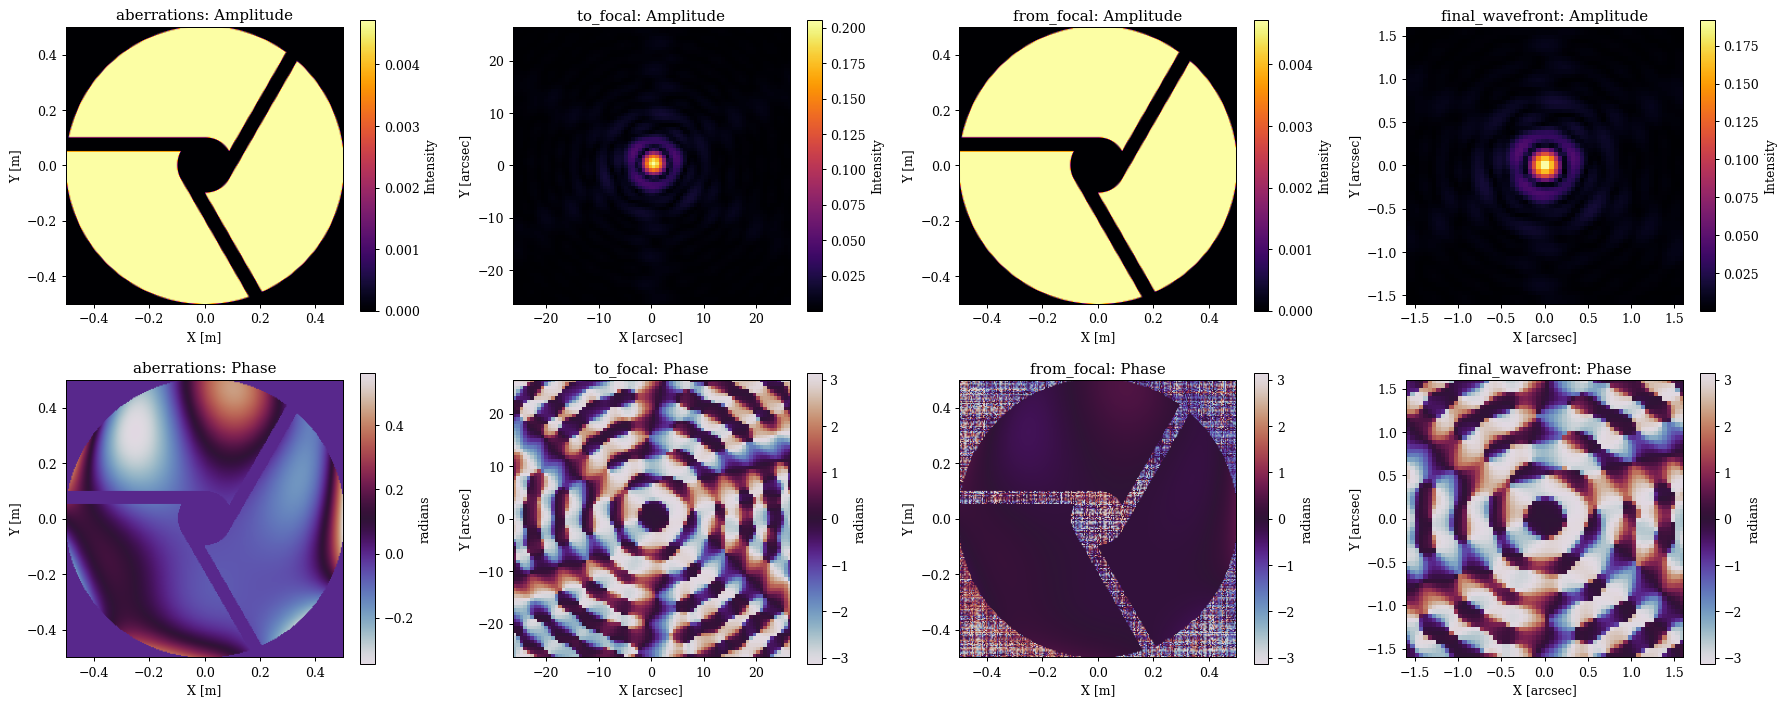

In [4]:
## COLLAPSE: Plotting code
plt.figure(figsize=(20, 8))
for i, name in enumerate(["aberrations", "to_focal", "from_focal", "final_wavefront"]):
    # Get the amplitude and phase of the wavefront
    wf = outputs[name]
    amp = np.abs(wf.amplitude)
    phase = wf.phase

    # Get the units and extent
    diam = wf.diameter
    if wf.units == "Cartesian" and wf.plane == "Pupil":
        unit = "m"
    elif wf.units == "Cartesian" and wf.plane == "Focal":
        unit = "mm"
        diam *= 1e3
    else:
        unit = "arcsec"
        diam = dlu.rad2arcsec(diam)
    ext = dlu.imshow_extent(diam)

    # Cut out the central region of the focal plane for better visualisation
    if name == "to_focal":
        s = 40
        c = amp.shape[0] // 2
        amp = amp[c - s : c + s, c - s : c + s]
        phase = phase[c - s : c + s, c - s : c + s]

    # Plot the plane
    ax = plt.subplot(2, 4, i+1)
    im = ax.imshow(amp, extent=ext)
    plt.colorbar(im, ax=ax, label="Intensity")
    ax.set(title=f"{name}: Amplitude", xlabel=f"X [{unit}]", ylabel=f"Y [{unit}]")

    ax = plt.subplot(2, 4, i+5)
    im = ax.imshow(phase, "twilight", extent=ext)
    plt.colorbar(im, ax=ax, label="radians")
    ax.set(title=f"{name}: Phase", xlabel=f"X [{unit}]", ylabel=f"Y [{unit}]")

plt.tight_layout()
plt.show()

---

## Building the Focal Plane Mask and Lyot Stop

Great, as we can see we essentially get the same psf at the intermediate focal plane and the final plane, which is what we would expect since we haven't added any components in the focal plane yet. Now lets build the focal plane mask and insert it into our system.

For this focal plane mask, we will use a simple dynamic circular aperture. We choose to make it dynamic so we can propagate _multiple_ wavelengths through the system and generate the mask at the correct pixel scale for each wavelength. We can parametrise this mask however we want, here we will define its size in lambda/D units (for a target wavelength) and also add an xy shift so we can represent mask misalignments. If you are unfamiliar with the aperture generating syntax, you can check our our apertures tutorial to get the basic idea. Let see how we can do this now.

In [5]:
# Create a child-class of OpticalLayer, so dLux can recognise it as a layer
class FocalPlaneMsk(dl.OpticalLayer):
    """Applies a dynamic circular focal plane mask to the wavefront in FFT coordinates."""
    radius: float  # Focal plane mask radius in lambda / D units
    shift: np.ndarray  # Shift of the focal plane mask, in lambda / D units
    scale: float # Size of lambda / D in radians

    def __init__(self, radius=2.0, scale=1., shift=None):
        self.radius = np.array(radius, float)
        self.scale = np.array(scale, float)
        if shift is None:
            shift = np.zeros(2)
        self.shift = np.array(shift, float)

    def __call__(self, wavefront):
        """
        Applies the focal plane mask to the wavefront. Assumes the wavefront is in 
        FFT coordinates.
        """
        # Get the wavefront coordinates and shift them, making sure we get the 
        # FFT-centered coordinates since we got here with an FFT!
        fp_coords = wavefront.coordinates(fft_style=True)
        fp_coords = dlu.translate_coords(fp_coords, -self.shift * self.scale)

        # Calculate the focal plane mask with a soft-edge and apply it
        softness = 0.5 * wavefront.pixel_scale
        radius_phys = self.radius * self.scale
        fp_mask = dlu.soft_circle(fp_coords, radius_phys, softness, invert=True)
        wavefront *= fp_mask

        # Return the wavefront with the focal plane mask applied
        return wavefront

# Generate the focal plane mask, targeting a wavelength of 1 micron
fpm = FocalPlaneMsk(radius=2, shift=[0, 0], scale=1e-6 / diameter)

# Examine
print(fpm)

FocalPlaneMsk(radius=f32[], shift=f32[2], scale=f32[])


Great now lets construct the Lyot-stop layer. We will also make this a dynamic circular aperture, not because the wavefront pixel scale changes in the Lyot plane, but so we can solve for the optimal size of the Lyot stop by making it a parameter and optimising it later. Since we also have our aperture spiders, we will store a copy of the aperture in this layer and also apply it. We will also add a shift here to represent misalignments. The process is more or less the same here.

In [6]:
# Create a child-class of OpticalLayer, so dLux can recognise it as a layer
class LyotMask(dl.OpticalLayer):
    """Applies a dynamic circular Lyot mask to the wavefront in FFT coordinates."""
    undersize: float  # Lyot mask undersize, ie 0.9 = 90% of the pupil radius
    shift: np.ndarray  # Shift of the Lyot mask, in physical units (i.e. meters)
    aperture: np.ndarray  # The static aperture to apply in the Lyot plane, including spiders

    def __init__(self, undersize=1., shift=None, aperture=None):
        self.undersize = np.array(undersize, float)
        if shift is None:
            shift = np.zeros(2)
        self.shift = np.array(shift, float)
        if aperture is None:
            aperture = np.array(1.) # empty mask if not provided
        self.aperture = np.array(aperture, float)

    def __call__(self, wavefront):
        """Applies the Lyot stop to the wavefront."""

        # Get the wavefront coordinates and shift them,
        coords = wavefront.coordinates()
        coords = dlu.translate_coords(coords, -self.shift)

        # Calculate the Lyot mask with a soft-edge and apply it
        softness = 0.5 * wavefront.pixel_scale
        radius_phys = wavefront.diameter * self.undersize / 2
        lyot_stop = dlu.soft_circle(coords, radius_phys, softness)
        wavefront *= lyot_stop * self.aperture

        # Return the wavefront with the Lyot mask applied
        return wavefront
    
# Construct the Lyot mask, undersized to 95% of the pupil radius and with no shift
lyot = LyotMask(undersize=0.9, shift=[0, 0], aperture=aper)

# Examine
print(lyot)

LyotMask(undersize=f32[], shift=f32[2], aperture=f32[256,256])


Okay great, now lets see how we can insert these into our system. We can use the `insert_layer` method to insert a layer at any point in the system, we just need to specify the index of the layer we want to insert before. We will insert the focal plane mask after the first FFT, and the Lyot stop after the second FFT. We can use the same `("key", layer)` syntax as before to insert the layers with a name, which is useful for later when we want to access these layers to change their parameters.

In [7]:
# Insert our optical layers
coron = optics.insert_layer(("fpm", fpm), index=3)
coron = coron.insert_layer(("lyot", lyot), index=5)

# Examine the optics object again to see the new layers
coron

AngularOpticalSystem(
  wf_npixels=256,
  diameter=1.0,
  layers={
    'aperture': TransmissiveLayer(transmission=f32[256,256], normalise=True),
    'aberrations':
    BasisLayer(basis=f32[18,256,256], coefficients=f32[18], as_phase=False),
    'to_focal': FFT(focal_length=None, pad=4, crop=1),
    'fpm': FocalPlaneMsk(radius=f32[], shift=f32[2], scale=f32[]),
    'from_focal': FFT(focal_length=None, pad=1, crop=4),
    'lyot': LyotMask(undersize=f32[], shift=f32[2], aperture=f32[256,256])
  },
  psf_npixels=64,
  oversample=1,
  psf_pixel_scale=0.05
)

Great, now we can see we have our new layers in the system! Lets use the debug prop to have a look at the wavefronts in each plane again to see the effect of our new layers. We are also going to remove the wavefront aberrations for this part so we can see the effect of the coronagraph more clearly.

In [8]:
# Remove the wavefront error
coron = coron.multiply(coefficients=0.)

# Propagate a wavefront through the system and get the intermediate wavefronts
wf, outputs = coron.debug_propagate_mono(1e-6)

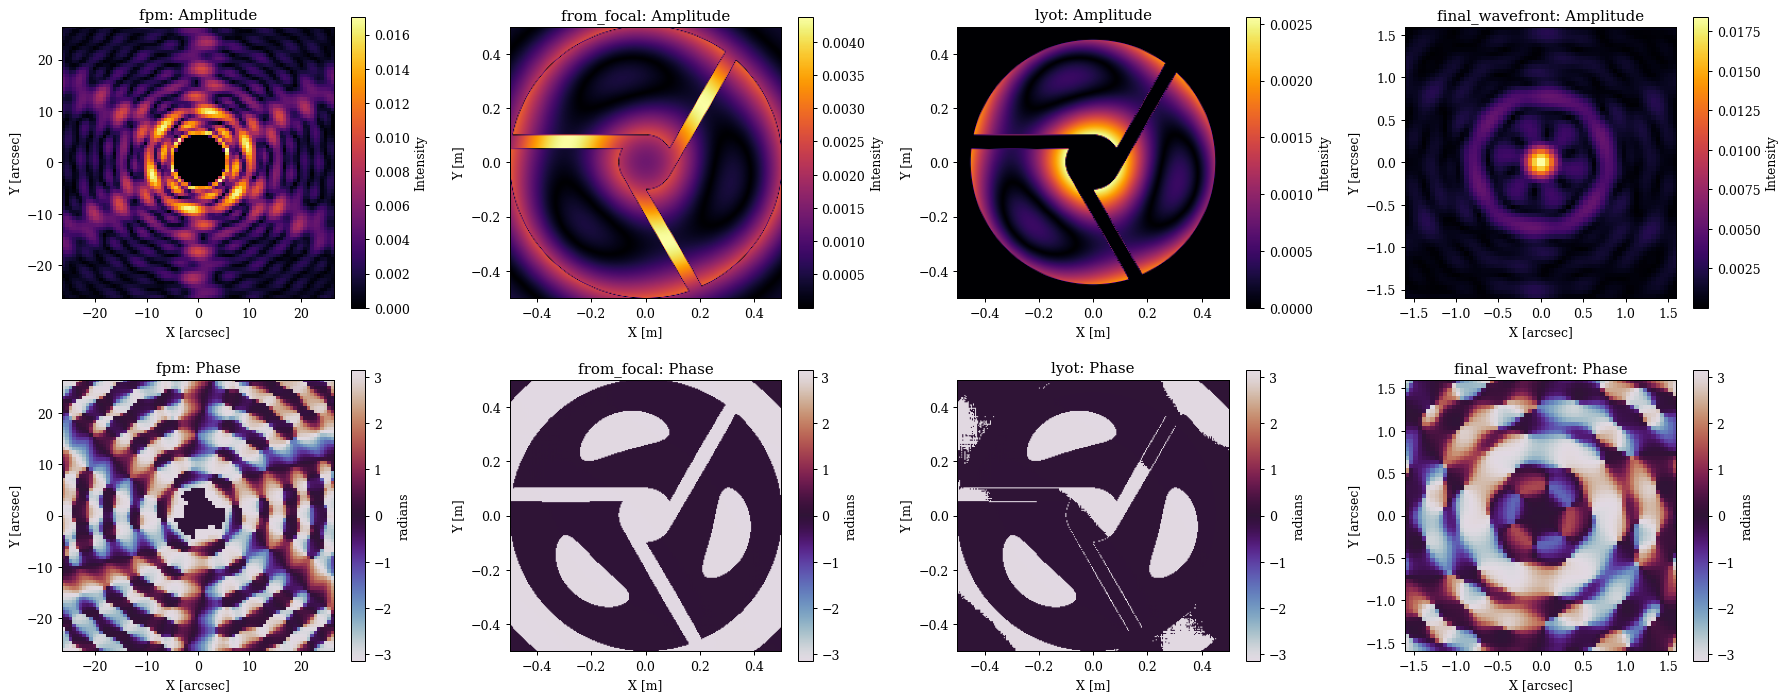

In [9]:
## COLLAPSE: Plotting code
plt.figure(figsize=(20, 8))
for i, name in enumerate(["fpm", "from_focal", "lyot", "final_wavefront"]):
    # Get the amplitude and phase of the wavefront
    wf = outputs[name]
    amp = np.abs(wf.amplitude)
    phase = wf.phase

    # Get the units and extent
    diam = wf.diameter
    if wf.units == "Cartesian" and wf.plane == "Pupil":
        unit = "m"
    elif wf.units == "Cartesian" and wf.plane == "Focal":
        unit = "mm"
        diam *= 1e3
    else:
        unit = "arcsec"
        diam = dlu.rad2arcsec(diam)
    ext = dlu.imshow_extent(diam)

    # Cut out the central region of the focal plane for better visualisation
    if name == "fpm":
        s = 40
        c = amp.shape[0] // 2
        amp = amp[c - s : c + s, c - s : c + s]
        phase = phase[c - s : c + s, c - s : c + s]

    # Plot the plane
    ax = plt.subplot(2, 4, i + 1)
    im = ax.imshow(amp, extent=ext)
    plt.colorbar(im, ax=ax, label="Intensity")
    ax.set(title=f"{name}: Amplitude", xlabel=f"X [{unit}]", ylabel=f"Y [{unit}]")

    ax = plt.subplot(2, 4, i + 5)
    im = ax.imshow(phase, "twilight", extent=ext)
    plt.colorbar(im, ax=ax, label="radians")
    ax.set(title=f"{name}: Phase", xlabel=f"X [{unit}]", ylabel=f"Y [{unit}]")

plt.tight_layout()
plt.show()

Now lets propagate a few PSFs through the system to see how the coronagraph performs as a function of source position

In [10]:
wavels = 1e-6 * np.linspace(0.9, 1., 3)
lamd = wavels.mean() / diameter
offsets = np.linspace(0, 4, 5)

psfs = []
for oset in offsets:
    offset = lamd * np.array([oset, 0])
    psf = coron.propagate(wavels, offset)
    psfs.append(psf)
psfs = np.array(psfs)

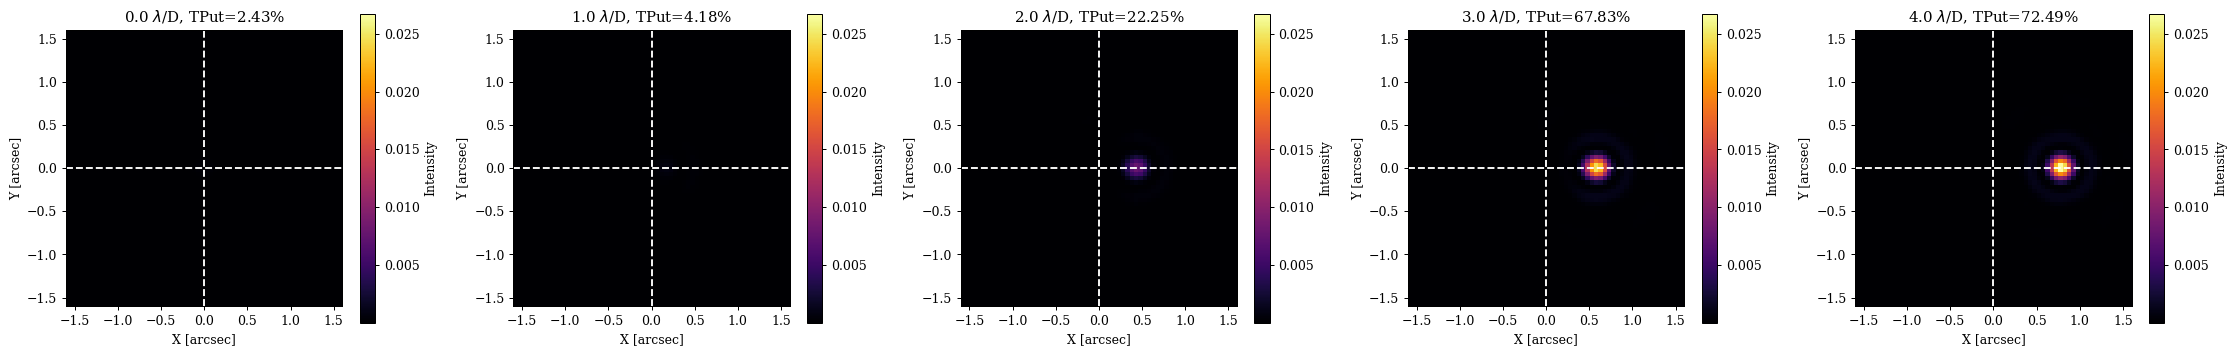

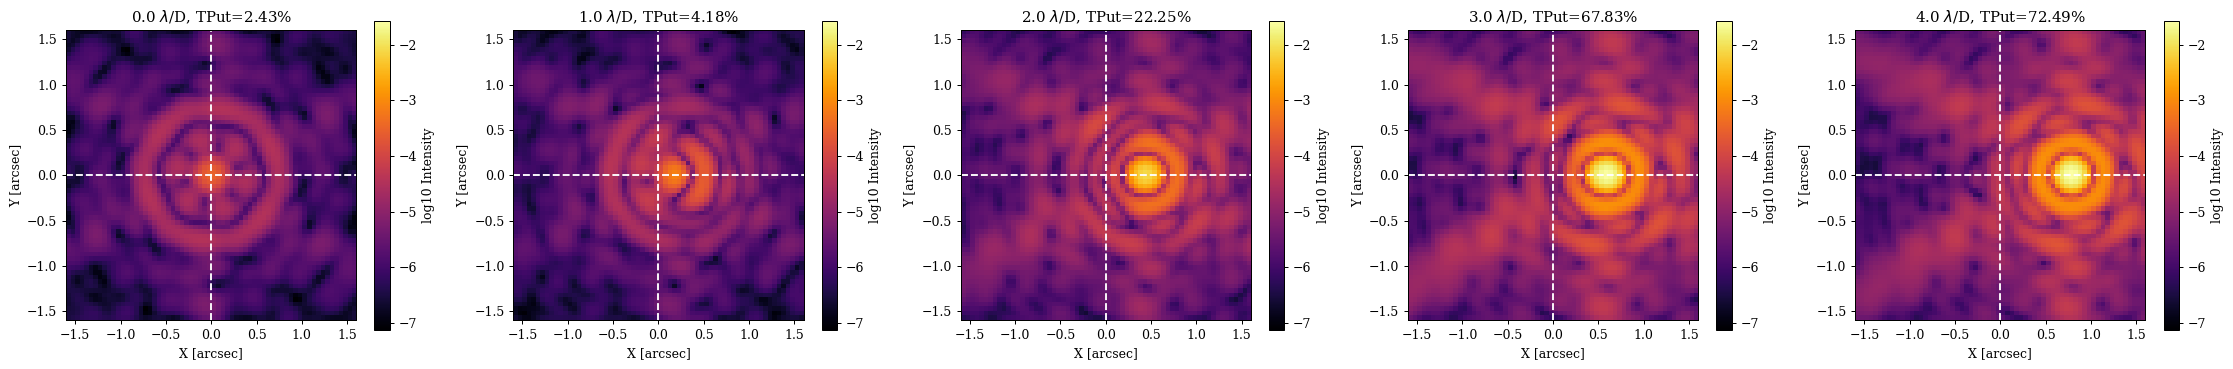

In [11]:
## COLLAPSE: Plotting code
ext = dlu.imshow_extent(coron.fov)

plt.figure(figsize=(25, 4))
for i in range(5):
    tp = 100 * psfs[i].sum()
    ax = plt.subplot(1, 5, i + 1)
    im = ax.imshow(psfs[i], vmax=np.max(psfs), extent=ext)
    plt.colorbar(im, ax=ax, label="Intensity")
    ax.set(
        xlabel="X [arcsec]",
        ylabel="Y [arcsec]",
        title=f"{offsets[i]:.1f} $\\lambda$/D, TPut={tp:.2f}%",
    )
    ax.axhline(0, color="w", ls="--")
    ax.axvline(0, color="w", ls="--")
plt.tight_layout()
plt.show()

vmin = np.min(np.log10(psfs))
vmax = np.max(np.log10(psfs))
plt.figure(figsize=(25, 4))
for i in range(5):
    tp = 100 * psfs[i].sum()
    ax = plt.subplot(1, 5, i + 1)
    im = ax.imshow(np.log10(psfs[i]), vmin=vmin, vmax=vmax, extent=ext)
    plt.colorbar(im, ax=ax, label="log10 Intensity")
    ax.set(
        xlabel="X [arcsec]",
        ylabel="Y [arcsec]",
        title=f"{offsets[i]:.1f} $\\lambda$/D, TPut={tp:.2f}%",
    )
    ax.axhline(0, color="w", ls="--")
    ax.axvline(0, color="w", ls="--")
plt.tight_layout()
plt.show()

---

## Coronagraph Optimisation

Now that we have our simple model, lets do a toy optimisation problem to show how we can use dLux to solve for optimal coronagraph parameters. For our metric we will use a simple annular contrast metric, where we want to minimise the flux in a 2-5 lambda/D annulus in the final focal plane, while maximising the average off-axis throughput of the companion sources. in that annulus. This is not meant to be rigorous by any sense, simply a demonstrative toy problem. 

Let set up the annular mask and the companion position and build our oss function.

In [12]:
# Focal plane coordinates
coords = dlu.pixel_coords(5 * optics.psf_npixels, optics.fov)
coords_lamd = dlu.arcsec2rad(coords) / lamd

# Annular mask to suppress starlight within
inner = dlu.circle(coords_lamd, 2, invert=True).astype(bool)
outer = dlu.circle(coords_lamd, 5).astype(bool)
annular_mask = dlu.downsample(outer & inner, 5)

# Companion PSF samples
positions = lamd * np.array([[2.5, 0], [3.5, 0], [4.5, 0]])

# Define the loss function
@eqx.filter_jit
@eqx.filter_value_and_grad
def loss_fn(params, coron):
    """Simple Loss function"""
    # fpm size, lyot size
    coron = coron.set(params)

    # Get the primary PSF throughput in the annular region
    primary = coron.propagate(wavels)
    primary_throughput = np.sum(annular_mask * primary)

    # Propagate companion PSFs
    companions = vmap(lambda pos: coron.propagate(wavels, pos))(positions)
    companion_throughput = companions.sum(axis=(1, 2)).mean(0)

    # Loss metric
    return np.log10(primary_throughput) - np.log10(companion_throughput)

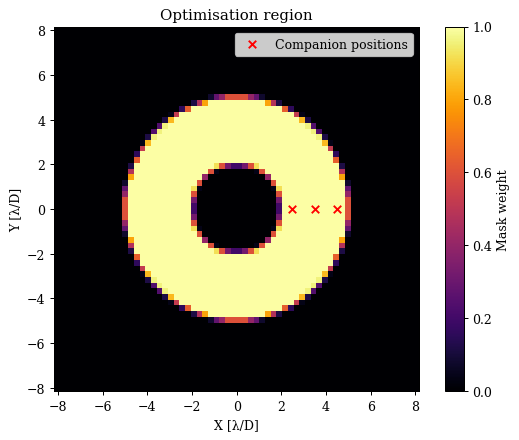

In [13]:
## COLLAPSE: Plotting code
ext_lamd = dlu.imshow_extent(dlu.arcsec2rad(coron.fov) / lamd)

## COLLAPSE: Plotting code
positions_lamd = positions / lamd
plt.figure(figsize=(6.5, 5))
ax = plt.subplot(1, 1, 1)
im = ax.imshow(annular_mask, extent=ext_lamd)
ax.scatter(*positions_lamd.T, color="r", marker="x", label="Companion positions")
plt.colorbar(im, ax=ax, label="Mask weight")
ax.set(title="Optimisation region", xlabel="X [λ/D]", ylabel="Y [λ/D]")
plt.legend()
plt.tight_layout()
plt.show()

Now lets run a little optimisation loop

In [14]:
# Set the initial parameters
params = {
    "fpm.radius": np.array(1.5),
    "lyot.undersize": np.array(0.95),
}

# Set up the optimisers for each parameter
optimisers = {
    "fpm.radius": optax.sgd(5e-2, momentum=0.5),
    "lyot.undersize": optax.sgd(1e-2, momentum=0.5),
}
optim, state = zdx.map_optimisers(params, optimisers)

# Now we can run a simple optimisation loop
epochs = 25
pbar = tqdm(range(epochs))
losses, params_history = [], []
for step in pbar:
    loss, grads = loss_fn(params, coron)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    pbar.set_postfix(log_loss=f"{loss:.4f}")
    losses.append(loss)
    params_history.append(params)
losses = np.array(losses)

  0%|          | 0/25 [00:00<?, ?it/s]

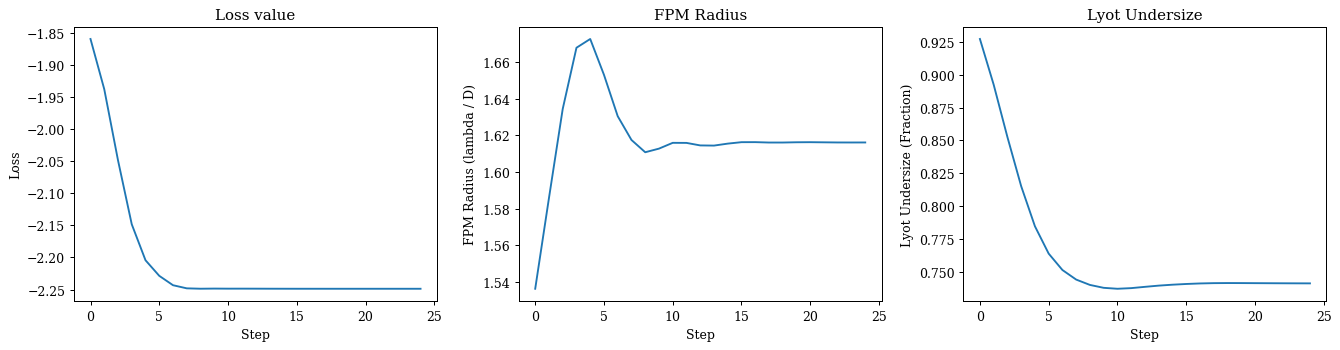

In [15]:
## COLLAPSE: Plotting
# Map the parameter history to arrays for plotting
values = {}
for param in params.keys():
    values[param] = np.array([params[param] for params in params_history])

# Plot the losses
plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 3, 1)
ax.plot(losses)
ax.set(title="Loss value", xlabel="Step", ylabel="Loss")

ax = plt.subplot(1, 3, 2)
ax.plot(values["fpm.radius"])
ax.set(title="FPM Radius", xlabel="Step", ylabel="FPM Radius (lambda / D)")

ax = plt.subplot(1, 3, 3)
ax.plot(values["lyot.undersize"])
ax.set(title="Lyot Undersize", xlabel="Step", ylabel="Lyot Undersize (Fraction)")

plt.tight_layout()
plt.show()

Nice that seems to have worked, lets propagate a few PSFs through the system to see how the coronagraph is doing. 

In [16]:
# Propagate some wavelengths thought the system
offsets = np.linspace(0, 4, 5)

psfs = []
for oset in offsets:
    offset = lamd * np.array([oset, 0])
    psf = coron.set(params).propagate(wavels, offset)
    psfs.append(psf)
psfs = np.array(psfs)

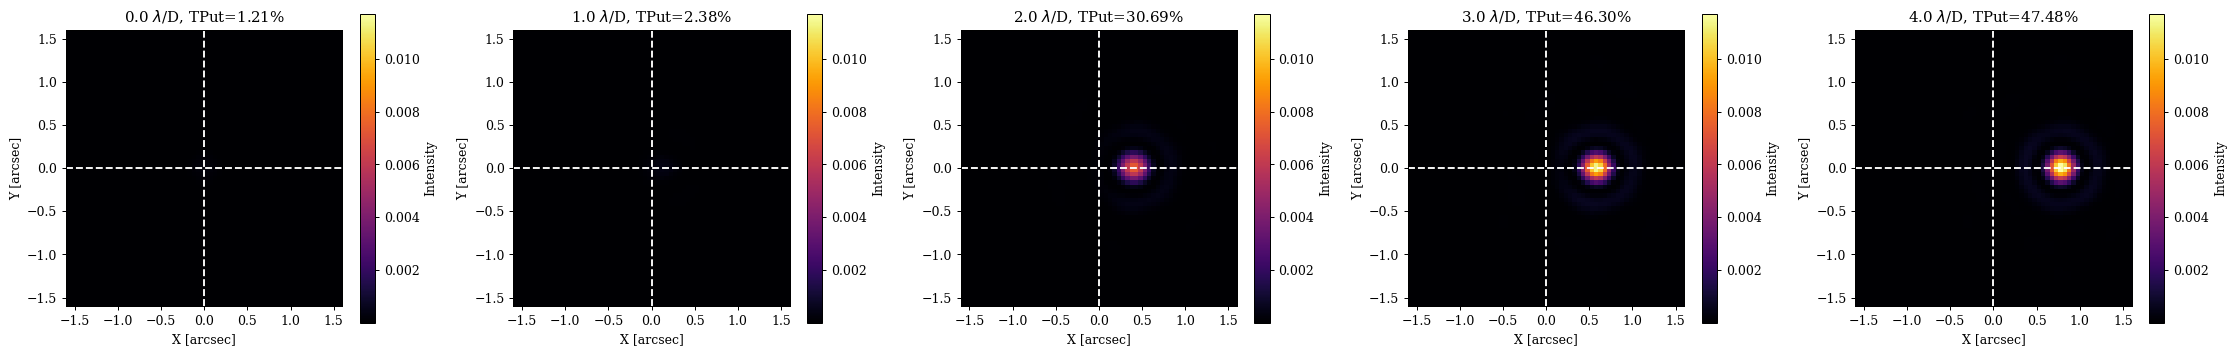

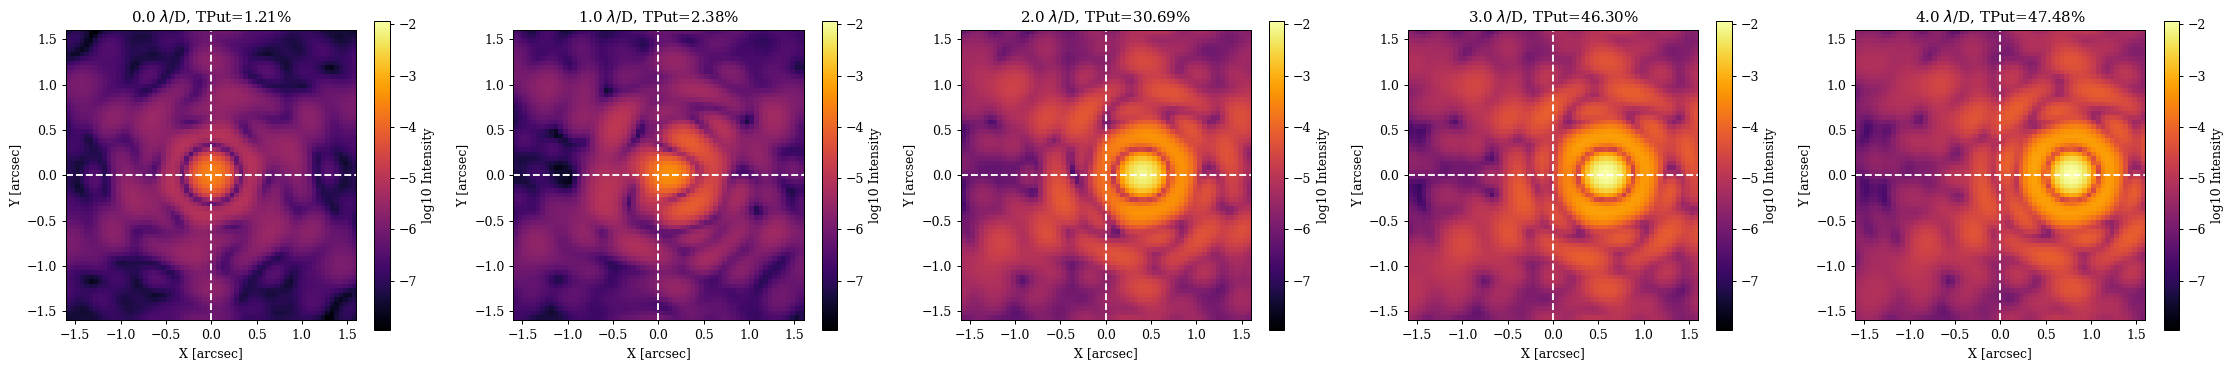

In [17]:
## COLLAPSE: Plotting code
ext = dlu.imshow_extent(coron.fov)

plt.figure(figsize=(25, 4))
for i in range(5):
    tp = 100 * psfs[i].sum()
    ax = plt.subplot(1, 5, i + 1)
    im = ax.imshow(psfs[i], vmax=np.max(psfs), extent=ext)
    plt.colorbar(im, ax=ax, label="Intensity")
    ax.set(
        xlabel="X [arcsec]",
        ylabel="Y [arcsec]",
        title=f"{offsets[i]:.1f} $\\lambda$/D, TPut={tp:.2f}%",
    )
    ax.axhline(0, color="w", ls="--")
    ax.axvline(0, color="w", ls="--")
plt.tight_layout()
plt.show()

vmin = np.min(np.log10(psfs))
vmax = np.max(np.log10(psfs))
plt.figure(figsize=(25, 4))
for i in range(5):
    tp = 100 * psfs[i].sum()
    ax = plt.subplot(1, 5, i + 1)
    im = ax.imshow(np.log10(psfs[i]), vmin=vmin, vmax=vmax, extent=ext)
    plt.colorbar(im, ax=ax, label="log10 Intensity")
    ax.set(
        xlabel="X [arcsec]",
        ylabel="Y [arcsec]",
        title=f"{offsets[i]:.1f} $\\lambda$/D, TPut={tp:.2f}%",
    )
    ax.axhline(0, color="w", ls="--")
    ax.axvline(0, color="w", ls="--")
plt.tight_layout()
plt.show()

---

## A Soummer MFT-style Coronagraph

Okay so now lets see how we can implement another algorithm for modelling the focal plane mask, which is based on the method from Soummer et al. 2007, which allows us to model complex high-res focal plane masks without needing to propagate very large wavefronts. To do this, we will construct a new custom layer that replaces our FFT's with MFTs - A fourier transform that allows us to specify the output sampling of our propagation. This lets us propagate _every_ wavelength through our system to the same pixel scale in the focal plane - this is the same algorithm dLux uses by default to propagate to the final focal plane for polychromatic PSFs. The key here is that we can now use a focal plane mask with very fine features (That would otherwise require very large padding and arrays for FFT based propagations) or ones that are non-parametric and can't be generated analytically for each wavelength. 

Lets create this new layer now, where we will use a gaussian shaped transmissive mask raised to a power to be able to tune the shape.

In [18]:
class SoummerFPM(dl.OpticalLayer):
    """
    Implements the Soummer et al. (2007) algorithm to apply a high-res focal plane
    mask without large FFTs.
    """
    lamd: float  # The size of the an optical fringe
    sigma: float  # The standard deviation of the Gaussian mask in lambda / D units
    power: float  # The power to raise the Gaussian mask to
    npixels: int  # The number of pixels in the focal plane mask
    pixel_scale: float  # The pixel scale of the focal plane mask, in lamda / D units

    def __init__(self, npixels, pixel_scale, lamd, sigma=1., power=5.):
        self.npixels = int(npixels)
        self.pixel_scale = np.array(pixel_scale, float)
        self.lamd = np.array(lamd, float)
        self.sigma = np.array(sigma, float)
        self.power = np.array(power, float)

    @property
    def mask(self):
        """Makes the gaussian mask"""
        radius = self.npixels * self.pixel_scale / (2 * self.lamd)
        mask = dlu.gaussian((0., 0.), self.sigma, self.npixels, extent=radius)
        return (1 - mask / mask.max()) ** self.power

    def __call__(self, wavefront):
        """Applies the focal plane mask to the wavefront."""
        # MFT propagate to the focal plane and apply the mask
        npixels = self.mask.shape[0]
        fp_wf = wavefront.propagate(npixels, self.pixel_scale)
        fp_wf = fp_wf.multiply(phasor=1 - self.mask)

        # Inverse MFT propagate back to the pupil plane
        npixels = wavefront.npixels
        pixel_scale = wavefront.pixel_scale
        pup_wf = fp_wf.propagate(npixels, pixel_scale, inverse=True)

        # Subtract wavefront from the original the get the applied mask
        return wavefront - pup_wf

# Construct our Soummer Focal plane mask layer
fpm = SoummerFPM(npixels=128, pixel_scale=lamd/5, lamd=lamd, sigma=1.)

# Examine the new layer
print(fpm)

SoummerFPM(lamd=f32[], sigma=f32[], power=f32[], npixels=128, pixel_scale=f32[])


Now we can construct our new system using this new layer, rather than the FFTs. We will also re-use our Lyot stop layer from before to make this a more complete system.

In [19]:
# Define the optical layers
layers = [
    ("aperture", dl.TransmissiveLayer(aper, normalise=True)),
    ("aberrations", dl.BasisLayer(basis)),
    ("fpm", fpm),
    ("lyot", lyot),
]

# Construct the optics object
coron = dl.AngularOpticalSystem(
    wf_npixels=wf_npix,
    diameter=diameter,
    layers=layers,
    psf_npixels=psf_npix,
    psf_pixel_scale=psf_pixel_scale,
)

# Examine the optics object again to see the new layers
print(coron)

AngularOpticalSystem(
  wf_npixels=256,
  diameter=1.0,
  layers={
    'aperture': TransmissiveLayer(transmission=f32[256,256], normalise=True),
    'aberrations':
    BasisLayer(basis=f32[18,256,256], coefficients=f32[18], as_phase=False),
    'fpm':
    SoummerFPM(
      lamd=f32[], sigma=f32[], power=f32[], npixels=128, pixel_scale=f32[]
    ),
    'lyot': LyotMask(undersize=f32[], shift=f32[2], aperture=f32[256,256])
  },
  psf_npixels=64,
  oversample=1,
  psf_pixel_scale=0.05
)


Now lets do a debug propagation again to examine the wavefronts at each plane and make sure everything is working. Note that since we are propagating to the focal plane, applying the mask, and inverse propagating back to the Lyot plane all in one layer, we no longer see the wavefront in the focal plane, since it is not an intermediate plane anymore, but we can still see the effect of the mask in the Lyot plane and the final focal plane.

In [20]:
wf, outputs = coron.debug_propagate_mono(1e-6)

Examine the wavefronts

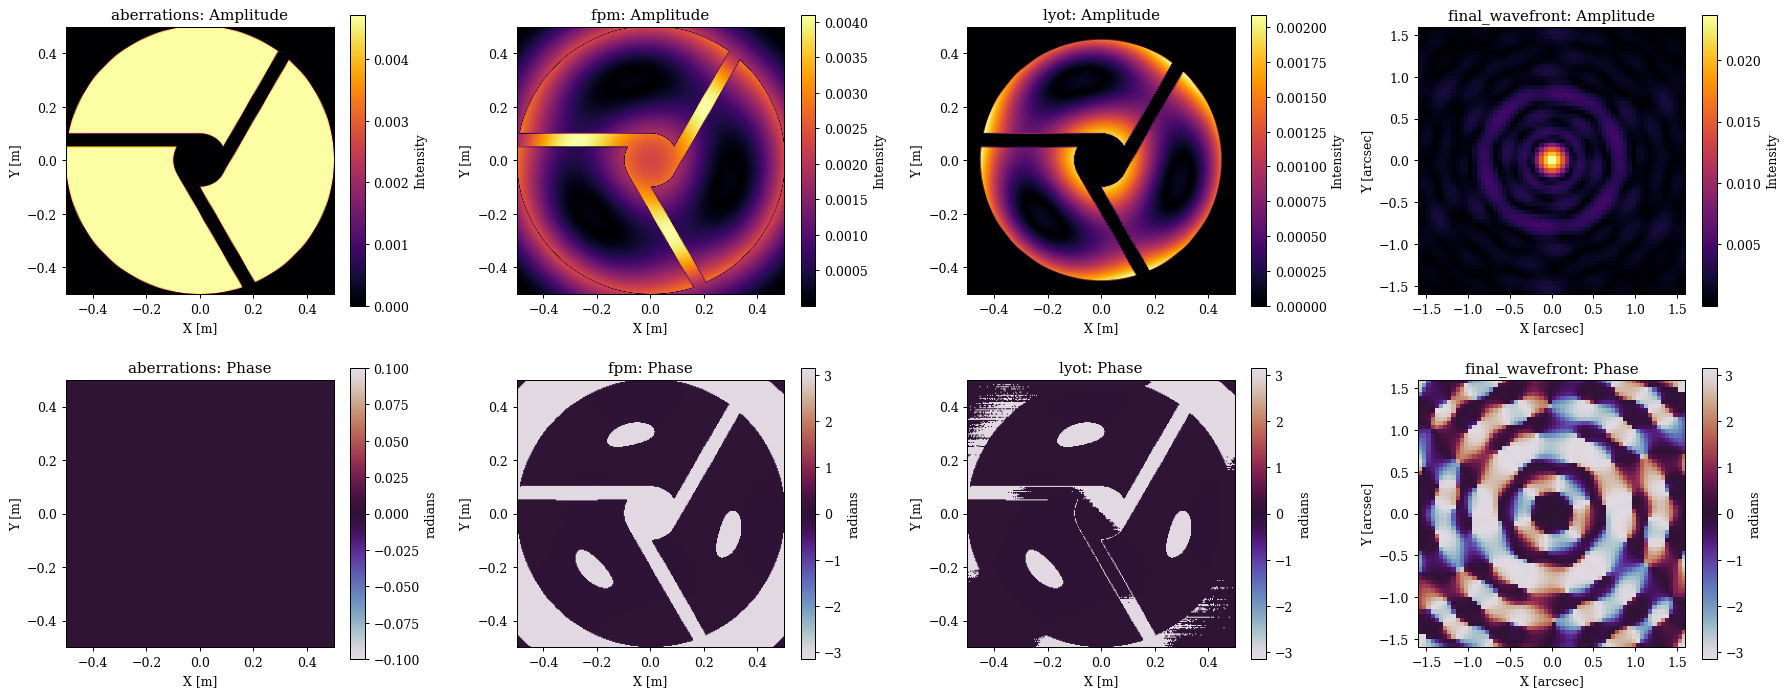

In [21]:
## COLLAPSE: Plotting code
plt.figure(figsize=(20, 8))
for i, name in enumerate(["aberrations", "fpm", "lyot", "final_wavefront"]):
    # Get the amplitude and phase of the wavefront
    wf = outputs[name]
    amp = np.abs(wf.amplitude)
    phase = wf.phase

    # Get the units and extent
    diam = wf.diameter
    if wf.units == "Cartesian" and wf.plane == "Pupil":
        unit = "m"
    elif wf.units == "Cartesian" and wf.plane == "Focal":
        unit = "mm"
        diam *= 1e3
    else:
        unit = "arcsec"
        diam = dlu.rad2arcsec(diam)
    ext = dlu.imshow_extent(diam)

    # Plot the plane
    ax = plt.subplot(2, 4, i + 1)
    im = ax.imshow(amp, extent=ext)
    plt.colorbar(im, ax=ax, label="Intensity")
    ax.set(title=f"{name}: Amplitude", xlabel=f"X [{unit}]", ylabel=f"Y [{unit}]")

    ax = plt.subplot(2, 4, i + 5)
    im = ax.imshow(phase, "twilight", extent=ext)
    plt.colorbar(im, ax=ax, label="radians")
    ax.set(title=f"{name}: Phase", xlabel=f"X [{unit}]", ylabel=f"Y [{unit}]")

plt.tight_layout()
plt.show()

This looks good, so now lets propagate a source at a few different offsets to see how the off-axis throughput of the companion sources changes with the new mask.

In [22]:
# Propagate some wavelengths thought the system
offsets = np.linspace(0, 4, 5)

psfs = []
for oset in offsets:
    offset = lamd * np.array([oset, 0])
    psf = coron.propagate(wavels, offset)
    psfs.append(psf)
psfs = np.array(psfs)

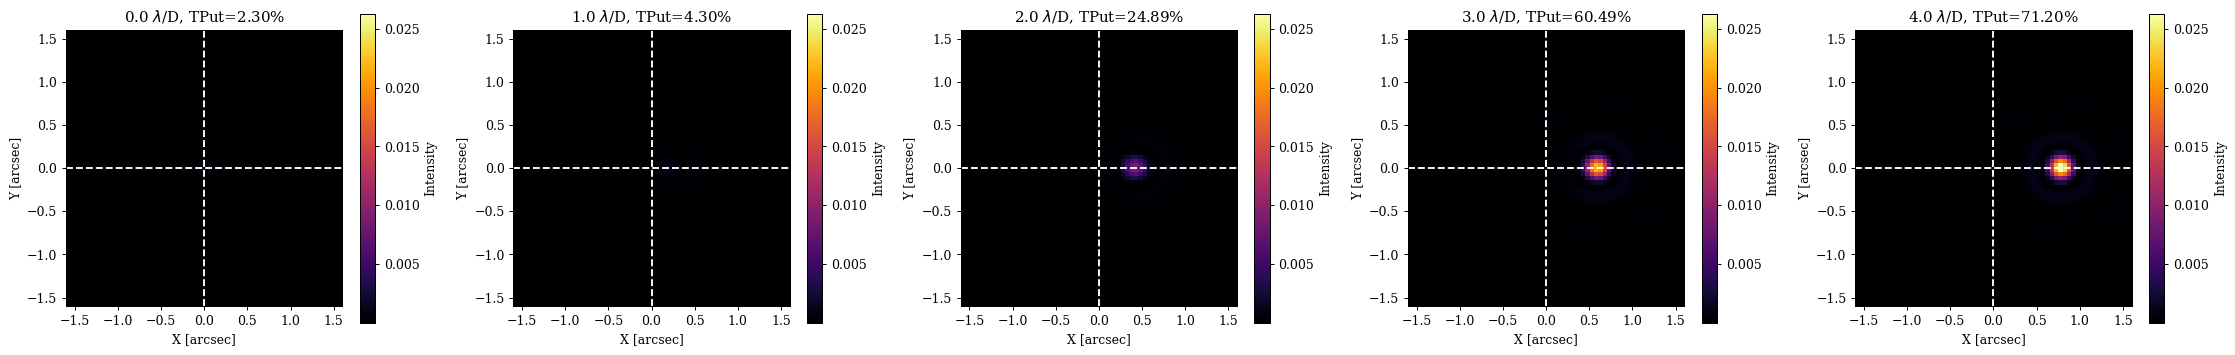

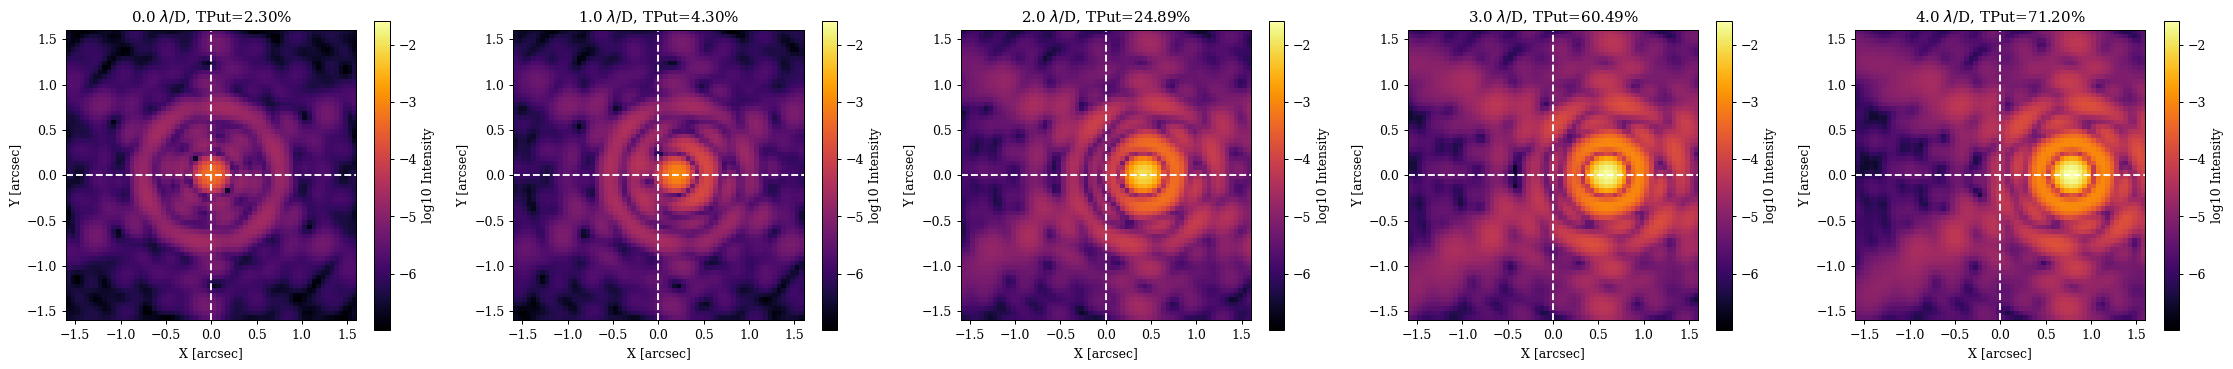

In [23]:
## COLLAPSE: Plotting code
ext = dlu.imshow_extent(coron.fov)

plt.figure(figsize=(25, 4))
for i in range(5):
    tp = 100 * psfs[i].sum()
    ax = plt.subplot(1, 5, i + 1)
    im = ax.imshow(psfs[i], vmax=np.max(psfs), extent=ext)
    plt.colorbar(im, ax=ax, label="Intensity")
    ax.set(
        xlabel="X [arcsec]",
        ylabel="Y [arcsec]",
        title=f"{offsets[i]:.1f} $\\lambda$/D, TPut={tp:.2f}%",
    )
    ax.axhline(0, color="w", ls="--")
    ax.axvline(0, color="w", ls="--")
plt.tight_layout()
plt.show()

vmin = np.min(np.log10(psfs))
vmax = np.max(np.log10(psfs))
plt.figure(figsize=(25, 4))
for i in range(5):
    tp = 100 * psfs[i].sum()
    ax = plt.subplot(1, 5, i + 1)
    im = ax.imshow(np.log10(psfs[i]), vmin=vmin, vmax=vmax, extent=ext)
    plt.colorbar(im, ax=ax, label="log10 Intensity")
    ax.set(
        xlabel="X [arcsec]",
        ylabel="Y [arcsec]",
        title=f"{offsets[i]:.1f} $\\lambda$/D, TPut={tp:.2f}%",
    )
    ax.axhline(0, color="w", ls="--")
    ax.axvline(0, color="w", ls="--")
plt.tight_layout()
plt.show()

Awesome, this all looks great. So, lets follow our same process as before and do a little optimisation to see if we can improve the performance of this new mask by tuning the parameters. 

Since our focal plane parameters are the same, we can just re-use our loss function from before and dive right in.

In [24]:
# Set the initial parameters
params = {
    "fpm.sigma": np.array(1.5),
    "lyot.undersize": np.array(0.9),
}

# Set up the optimisers for each parameter
optimisers = {
    "fpm.sigma": optax.sgd(5e-2, momentum=0.5),
    "lyot.undersize": optax.sgd(2e-3, momentum=0.5),
}
optim, state = zdx.map_optimisers(params, optimisers)

# Now we can run a simple optimisation loop
epochs = 100
pbar = tqdm(range(epochs))
losses, params_history = [], []
for step in pbar:
    loss, grads = loss_fn(params, coron)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    pbar.set_postfix(log_loss=f"{loss:.4f}")
    losses.append(loss)
    params_history.append(params)
losses = np.array(losses)

  0%|          | 0/100 [00:00<?, ?it/s]

Cool, lets have a look at our optimisation

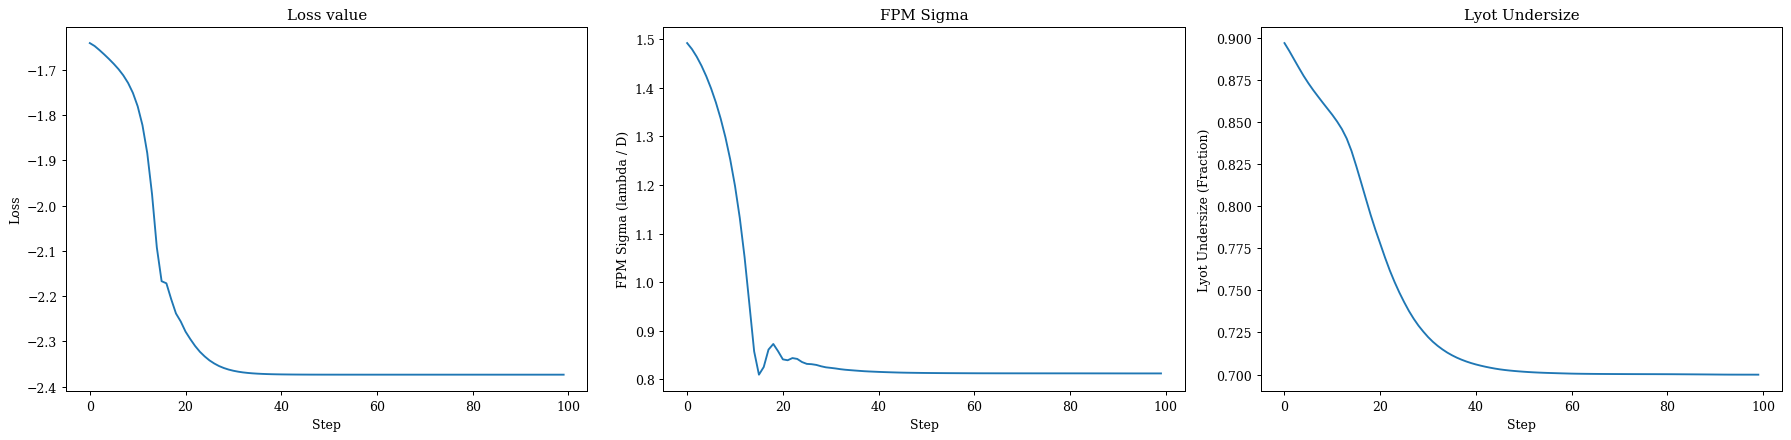

In [25]:
## COLLAPSE: Plotting
# Map the parameter history to arrays for plotting
values = {}
for param in params.keys():
    values[param] = np.array([params[param] for params in params_history])

# Plot the losses
plt.figure(figsize=(20, 5))
ax = plt.subplot(1, 3, 1)
ax.plot(losses)
ax.set(title="Loss value", xlabel="Step", ylabel="Loss")

ax = plt.subplot(1, 3, 2)
ax.plot(values["fpm.sigma"])
ax.set(title="FPM Sigma", xlabel="Step", ylabel="FPM Sigma (lambda / D)")

ax = plt.subplot(1, 3, 3)
ax.plot(values["lyot.undersize"])
ax.set(title="Lyot Undersize", xlabel="Step", ylabel="Lyot Undersize (Fraction)")

plt.tight_layout()
plt.show()

Now lets propagate a few PSFs through the system to see how the coronagraph is doing with the new mask.

In [26]:
# Propagate some wavelengths thought the system
offsets = np.linspace(0, 4, 5)

psfs = []
for oset in offsets:
    offset = lamd * np.array([oset, 0])
    psf = coron.set(params).propagate(wavels, offset)
    psfs.append(psf)
psfs = np.array(psfs)

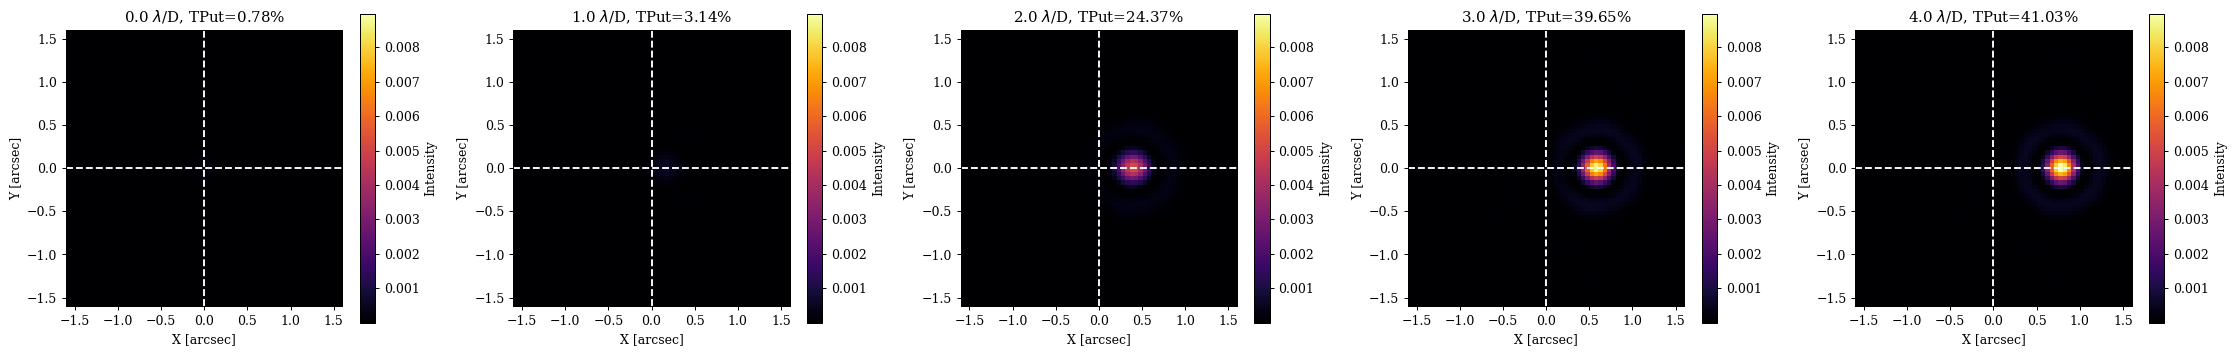

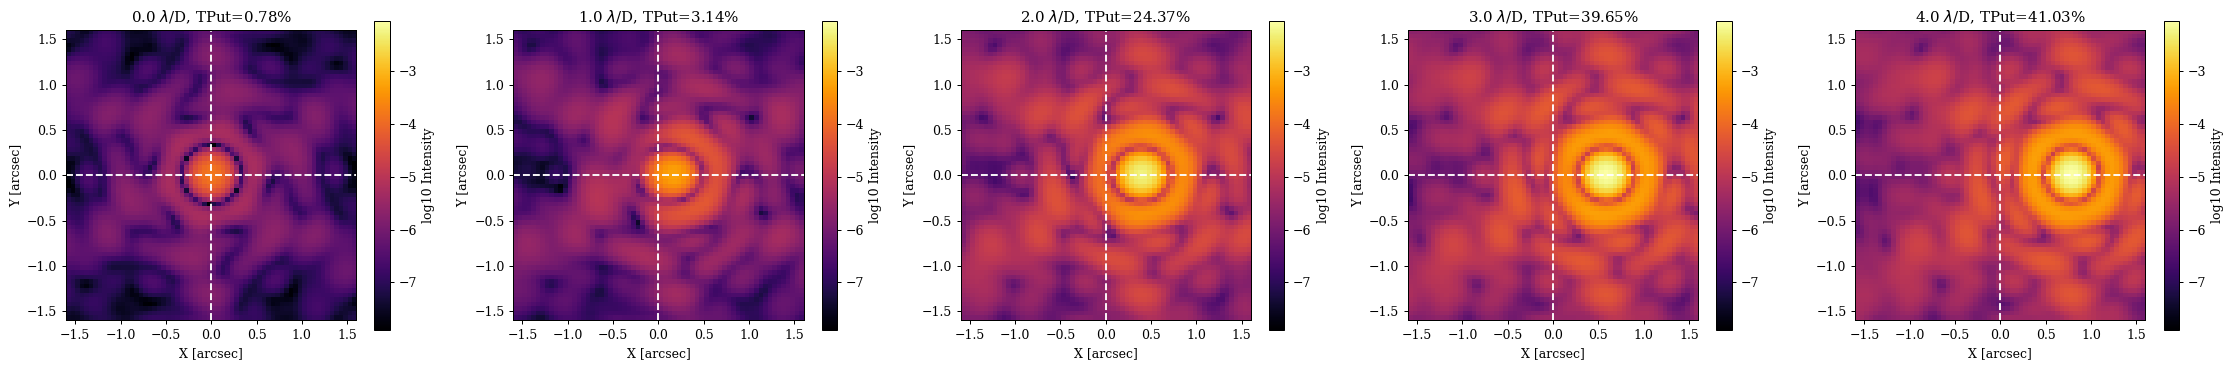

In [27]:
## COLLAPSE: Plotting code
ext = dlu.imshow_extent(coron.fov)

plt.figure(figsize=(25, 4))
for i in range(5):
    tp = 100 * psfs[i].sum()
    ax = plt.subplot(1, 5, i + 1)
    im = ax.imshow(psfs[i], vmax=np.max(psfs), extent=ext)
    plt.colorbar(im, ax=ax, label="Intensity")
    ax.set(
        xlabel="X [arcsec]",
        ylabel="Y [arcsec]",
        title=f"{offsets[i]:.1f} $\\lambda$/D, TPut={tp:.2f}%",
    )
    ax.axhline(0, color="w", ls="--")
    ax.axvline(0, color="w", ls="--")
plt.tight_layout()
plt.show()

vmin = np.min(np.log10(psfs))
vmax = np.max(np.log10(psfs))
plt.figure(figsize=(25, 4))
for i in range(5):
    tp = 100 * psfs[i].sum()
    ax = plt.subplot(1, 5, i + 1)
    im = ax.imshow(np.log10(psfs[i]), vmin=vmin, vmax=vmax, extent=ext)
    plt.colorbar(im, ax=ax, label="log10 Intensity")
    ax.set(
        xlabel="X [arcsec]",
        ylabel="Y [arcsec]",
        title=f"{offsets[i]:.1f} $\\lambda$/D, TPut={tp:.2f}%",
    )
    ax.axhline(0, color="w", ls="--")
    ax.axvline(0, color="w", ls="--")
plt.tight_layout()
plt.show()

Awesome, as we can see, we now have a new optimised coronograph! Interestingly, compared to our first system we can see that this new mask has much better on-axis supression, but worse off-axis throughput, which is what we would expect since the gaussian mask better matches the PSF shape, but also has more extended wings than the hard edged mask, which will block more of the off-axis companion light. This is a good example of how we can use dLux to quickly iterate on different designs and see the effect on performance, and then tune the parameters to find an optimal design.